# Notebook 2 — Seasonal Pollution Pattern Clustering 🌦️

**Objective:** Cluster City × Season combinations based on pollution and weather characteristics 
to analyze how environmental conditions vary across seasons and cities. The unit of analysis 
is a (City, Season) pair — yielding 28 observations (7 cities × 4 seasons).

Unlike Notebook 1 where we clustered cities as whole-year profiles, here we ask: 
*do the data-driven clusters align with the calendar seasons, or does pollution 
follow a different rhythm?*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 130
pd.set_option("display.float_format", "{:.3f}".format)

## Data Loading & Aggregation

The raw dataset contains daily observations per city. To perform seasonal clustering, 
we aggregate to the (City, Season) level — computing the mean of each pollutant and 
weather feature within each city-season combination.

**Feature selection for this task differs from Notebook 1:**
- ✅ Pollutants (PM2.5, O3, NO2, CO, SO2) — vary meaningfully across seasons
- ✅ Weather (Temperature_mean, Humidity, Wind_speed) — the primary drivers of seasonal variation
- ❌ Green_Space — constant per city, carries no seasonal signal
- ❌ Electricity Consumption — constant per city in this dataset
- ❌ Pressure — elevation artifact, constant per city
- ❌ PM10 — excluded due to high multicollinearity with PM2.5 (same reasoning as NB1)

In [2]:
df = pd.read_csv("../../Data/final/environment_data.csv")
df["Date"] = pd.to_datetime(df["Date"])

SEASON_ORDER = ["Winter", "Spring", "Summer", "Autumn"]
POLLUTANTS   = ["PM2.5", "O3", "NO2", "CO", "SO2"]
WEATHER      = ["Temperature_mean", "Humidity", "Wind_speed"]
FEATURES     = POLLUTANTS + WEATHER

df["Season"] = pd.Categorical(df["Season"], categories=SEASON_ORDER, ordered=True)

# Aggregate to City x Season level
season_profiles = df.groupby(["City", "Season"])[FEATURES].mean().round(3)

print("Shape:", season_profiles.shape)
print("\nIndex preview:")
print(season_profiles.index.tolist())
season_profiles

Shape: (28, 8)

Index preview:
[('Cairo', 'Winter'), ('Cairo', 'Spring'), ('Cairo', 'Summer'), ('Cairo', 'Autumn'), ('Dubai', 'Winter'), ('Dubai', 'Spring'), ('Dubai', 'Summer'), ('Dubai', 'Autumn'), ('London', 'Winter'), ('London', 'Spring'), ('London', 'Summer'), ('London', 'Autumn'), ('Nairobi', 'Winter'), ('Nairobi', 'Spring'), ('Nairobi', 'Summer'), ('Nairobi', 'Autumn'), ('New York', 'Winter'), ('New York', 'Spring'), ('New York', 'Summer'), ('New York', 'Autumn'), ('Paris', 'Winter'), ('Paris', 'Spring'), ('Paris', 'Summer'), ('Paris', 'Autumn'), ('Tokyo', 'Winter'), ('Tokyo', 'Spring'), ('Tokyo', 'Summer'), ('Tokyo', 'Autumn')]


PM2.5      O3    NO2      CO    SO2  Temperature_mean  \
City     Season                                                          
Cairo    Winter 29.362  39.600 40.793 378.202 43.194            16.553   
         Spring 27.730  67.576 30.052 259.007 32.621            22.479   
         Summer 23.399  84.545 22.317 220.082 25.536            29.647   
         Autumn 27.176  57.054 32.274 287.708 32.307            25.934   
Dubai    Winter 32.840  54.978 60.136 438.735 19.550            22.882   
         Spring 36.148  73.403 79.530 504.273 20.315            28.477   
         Summer 51.272 109.957 47.519 473.506 21.458            36.877   
         Autumn 42.569  77.362 43.662 446.262 22.227            32.083   
London   Winter 10.304  40.394 25.132 244.825  4.313             7.036   
         Spring  9.092  58.700 17.457 165.141  2.816            10.390   
         Summer  7.099  55.812 12.180 172.585  1.861            18.146   
         Autumn  8.868  40.301 21.803 225.689  2.953            13.559   
Nairobi  Winter 12.774  66.608  7.367 445.666  3.649            21.028   
         Spring 19.451  57.502 18.471 901.674  5.684            20.253   
         Summer 20.764  64.592 14.499 620.135  6.148            18.758   
         Autumn 10.097  55.293  6.574 278.515  3.677            20.515   
New York Winter 15.906  25.575 39.110 367.680  7.130             7.395   
         Spring 15.967  49.212 37.458 269.713  5.087            12.785   
         Summer 20.702  75.262 30.499 340.279  6.164            23.610   
         Autumn 13.203  39.819 29.647 322.138  6.716            15.861   
Paris    Winter 13.378  35.965 29.826 242.887  4.064             6.981   
         Spring 10.726  58.570 20.819 185.063  2.516            11.887   
         Summer  8.331  63.652 13.976 168.297  1.461            20.895   
         Autumn  8.673  43.149 23.890 229.065  2.545            14.844   
Tokyo    Winter 25.639  16.625 62.470 412.838 49.312             8.492   
         Spring 21.204  41.942 66.791 275.689 16.042            16.448   
         Summer 21.523  41.423 48.611 255.680 21.146            27.166   
         Autumn 26.973  29.412 45.565 347.887 34.391            20.859   

                 Humidity  Wind_speed  
City     Season                        
Cairo    Winter    60.595      10.538  
         Spring    46.015      14.297  
         Summer    51.904      13.777  
         Autumn    57.231      12.282  
Dubai    Winter    57.246      12.566  
         Spring    48.716      13.884  
         Summer    48.243      14.051  
         Autumn    52.989      12.615  
London   Winter    82.197      16.320  
         Spring    74.388      14.145  
         Summer    68.959      15.417  
         Autumn    79.977      14.007  
Nairobi  Winter    59.758      17.408  
         Spring    73.162      12.989  
         Summer    67.087      10.814  
         Autumn    70.353      14.414  
New York Winter    56.432      10.694  
         Spring    56.867      10.971  
         Summer    67.627       9.227  
         Autumn    67.212      10.557  
Paris    Winter    79.646      12.754  
         Spring    68.404      13.218  
         Summer    62.767      10.479  
         Autumn    76.375      10.671  
Tokyo    Winter    56.798      17.733  
         Spring    69.621      20.330  
         Summer    78.479      19.249  
         Autumn    70.035      17.371

## Feature Correlation Analysis

Before scaling and clustering, we inspect the correlation structure of the 
seasonal feature matrix. High correlations between features indicate redundancy 
that could distort distance-based clustering by over-weighting certain dimensions.

A threshold of |r| > 0.85 is used to flag problematic pairs, consistent with 
the approach in Notebook 1.

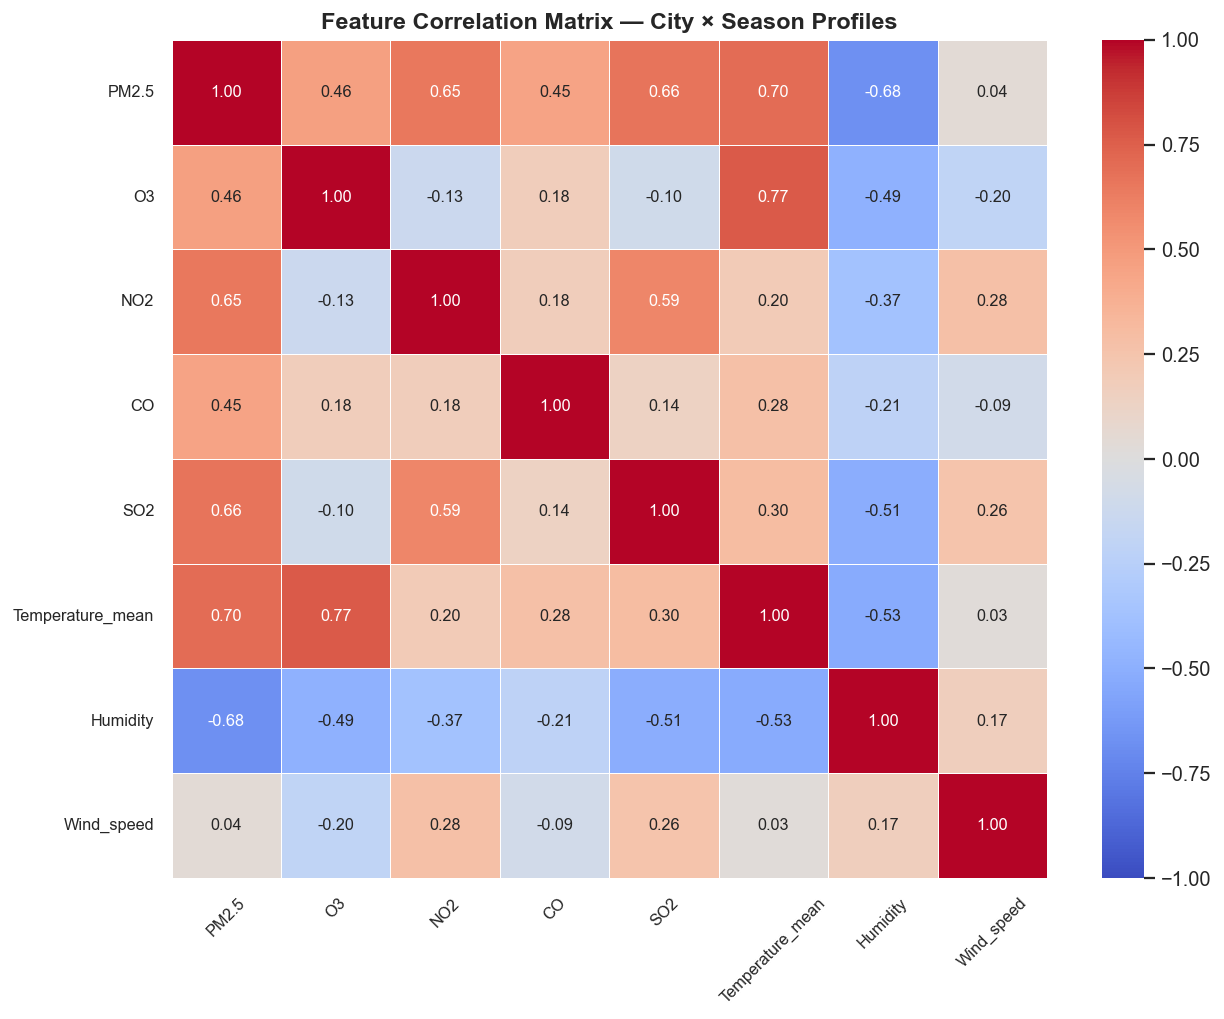

In [3]:
corr = season_profiles.corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    linecolor="white",
    ax=ax,
    annot_kws={"size": 9},
    vmin=-1, vmax=1
)
ax.set_title("Feature Correlation Matrix — City × Season Profiles", fontweight="bold", fontsize=13)
ax.tick_params(axis="x", rotation=45, labelsize=9)
ax.tick_params(axis="y", rotation=0, labelsize=9)
plt.tight_layout()
plt.show()

In [4]:
# Flag pairs above threshold
corr_unstacked = corr.abs().unstack()
high_corr = (
    corr_unstacked[corr_unstacked > 0.85]
    .reset_index()
    .rename(columns={"level_0": "Feature A", "level_1": "Feature B", 0: "Correlation"})
)
high_corr = high_corr[high_corr["Feature A"] != high_corr["Feature B"]]
high_corr = high_corr[high_corr["Feature A"] < high_corr["Feature B"]].sort_values("Correlation", ascending=False)

print("Feature pairs with |r| > 0.85:\n")
print(high_corr.to_string(index=False))

Feature pairs with |r| > 0.85:

Empty DataFrame
Columns: [Feature A, Feature B, Correlation]
Index: []


## Feature Scaling

All features are standardized using `StandardScaler` (zero mean, unit variance). 
This is necessary because pollutant concentrations (e.g. CO in hundreds of µg/m³) 
and weather variables (e.g. Wind_speed in single digits) operate on incompatible scales.

`StandardScaler` is preferred over `MinMaxScaler` for the same reason as Notebook 1 — 
it is more robust to the outliers present in seasonal pollution data 
(e.g. extreme summer ozone or winter particulate spikes).

In [5]:
scaler = StandardScaler()
season_scaled = scaler.fit_transform(season_profiles)

season_scaled_df = pd.DataFrame(
    season_scaled,
    index=season_profiles.index,
    columns=season_profiles.columns
)

print("Scaled shape:", season_scaled_df.shape)
season_scaled_df.round(3)

Scaled shape: (28, 8)


PM2.5     O3    NO2     CO    SO2  Temperature_mean  \
City     Season                                                        
Cairo    Winter  0.822 -0.769  0.420  0.255  2.115            -0.319   
         Spring  0.672  0.681 -0.171 -0.511  1.337             0.456   
         Summer  0.275  1.561 -0.596 -0.761  0.815             1.393   
         Autumn  0.621  0.136 -0.049 -0.327  1.314             0.907   
Dubai    Winter  1.141  0.028  1.483  0.644  0.375             0.508   
         Spring  1.444  0.983  2.549  1.065  0.431             1.240   
         Summer  2.830  2.879  0.789  0.867  0.515             2.338   
         Autumn  2.032  1.189  0.577  0.692  0.572             1.711   
London   Winter -0.925 -0.728 -0.441 -0.602 -0.747            -1.563   
         Spring -1.037  0.221 -0.863 -1.114 -0.857            -1.125   
         Summer -1.219  0.071 -1.153 -1.066 -0.928            -0.111   
         Autumn -1.057 -0.733 -0.624 -0.725 -0.847            -0.711   
Nairobi  Winter -0.699  0.631 -1.417  0.688 -0.796             0.266   
         Spring -0.087  0.159 -0.807  3.618 -0.646             0.165   
         Summer  0.033  0.527 -1.025  1.809 -0.612            -0.031   
         Autumn -0.944  0.044 -1.461 -0.386 -0.794             0.199   
New York Winter -0.412 -1.497  0.327  0.187 -0.540            -1.516   
         Spring -0.406 -0.271  0.236 -0.442 -0.690            -0.812   
         Summer  0.028  1.080 -0.146  0.011 -0.611             0.603   
         Autumn -0.660 -0.758 -0.193 -0.105 -0.570            -0.410   
Paris    Winter -0.644 -0.958 -0.183 -0.615 -0.765            -1.571   
         Spring -0.887  0.214 -0.678 -0.986 -0.879            -0.929   
         Summer -1.106  0.478 -1.054 -1.094 -0.957             0.248   
         Autumn -1.075 -0.585 -0.509 -0.703 -0.877            -0.543   
Tokyo    Winter  0.480 -1.961  1.611  0.477  2.566            -1.373   
         Spring  0.074 -0.648  1.848 -0.404  0.116            -0.333   
         Summer  0.103 -0.675  0.849 -0.532  0.492             1.068   
         Autumn  0.603 -1.298  0.682  0.060  1.467             0.244   

                 Humidity  Wind_speed  
City     Season                        
Cairo    Winter    -0.393      -1.118  
         Spring    -1.822       0.224  
         Summer    -1.245       0.038  
         Autumn    -0.723      -0.496  
Dubai    Winter    -0.722      -0.394  
         Spring    -1.557       0.076  
         Summer    -1.604       0.136  
         Autumn    -1.139      -0.377  
London   Winter     1.723       0.946  
         Spring     0.958       0.169  
         Summer     0.426       0.623  
         Autumn     1.506       0.120  
Nairobi  Winter    -0.475       1.334  
         Spring     0.838      -0.243  
         Summer     0.243      -1.020  
         Autumn     0.563       0.265  
New York Winter    -0.801      -1.063  
         Spring    -0.759      -0.964  
         Summer     0.296      -1.586  
         Autumn     0.255      -1.112  
Paris    Winter     1.473      -0.327  
         Spring     0.372      -0.162  
         Summer    -0.181      -1.139  
         Autumn     1.153      -1.071  
Tokyo    Winter    -0.765       1.450  
         Spring     0.491       2.377  
         Summer     1.359       1.991  
         Autumn     0.532       1.321

## Hierarchical Clustering — Dendrogram

Agglomerative hierarchical clustering with Ward linkage is applied to the scaled 
City × Season matrix. With 28 observations, the dendrogram remains visually 
interpretable and guides the choice of k before any K-Means is attempted.

Ward linkage is used consistently with Notebook 1 — it minimizes the increase 
in within-cluster variance at each merge step, producing compact and well-separated clusters.

The cut point (k) is determined by identifying the largest vertical gap 
in the dendrogram — the merge that required crossing the greatest distance.

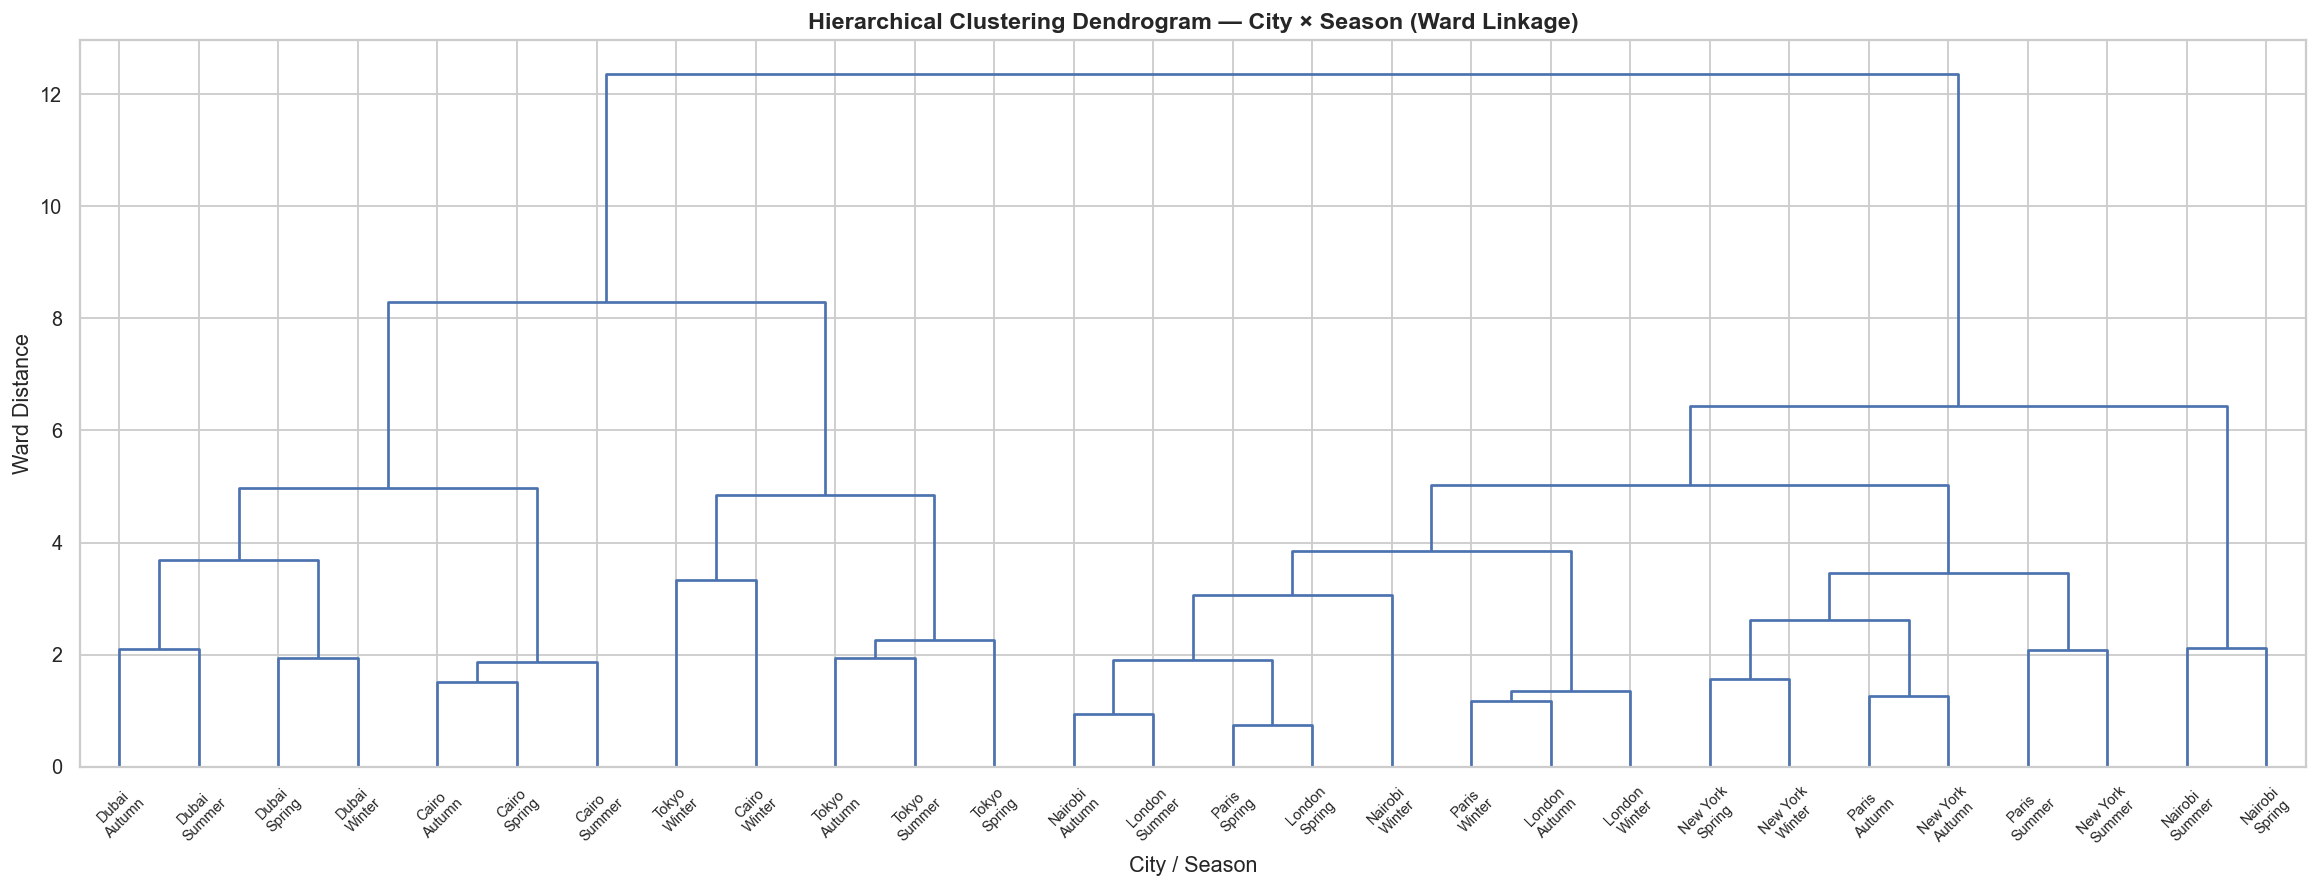

In [6]:
linked = linkage(season_scaled, method="ward")

labels = [f"{city}\n{season}" for city, season in season_profiles.index]

fig, ax = plt.subplots(figsize=(18, 7))
dendrogram(
    linked,
    labels=labels,
    orientation="top",
    distance_sort="descending",
    color_threshold=0,
    ax=ax,
    leaf_rotation=45,
    leaf_font_size=8
)

ax.set_title("Hierarchical Clustering Dendrogram — City × Season (Ward Linkage)", fontweight="bold", fontsize=13)
ax.set_xlabel("City / Season")
ax.set_ylabel("Ward Distance")
plt.tight_layout()
plt.show()

## K Selection — Elbow Method & Silhouette Score

Two independent methods are used to validate the k suggested by the dendrogram:

- **Elbow Method**: Plots within-cluster sum of squared errors (inertia) vs k. 
  The "elbow" — where the rate of inertia decrease flattens — indicates diminishing 
  returns from adding more clusters.

- **Silhouette Score**: Measures how well each observation fits its assigned cluster 
  relative to neighboring clusters. Ranges from -1 to 1; higher is better. 
  Used to confirm or challenge the elbow result.

Both are evaluated across k = 2 to 7.

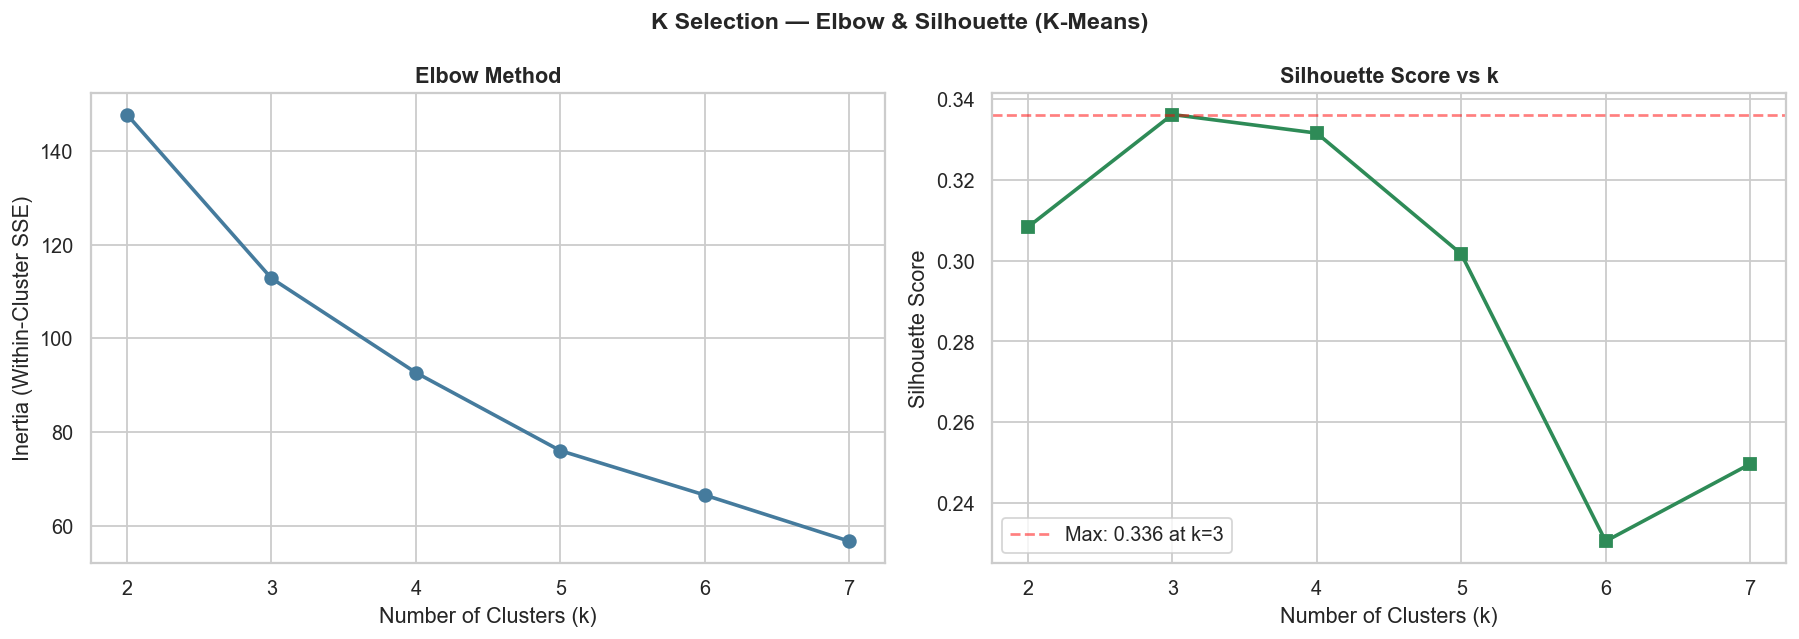

Silhouette Scores:
  k=2: 0.3083
  k=3: 0.3362
  k=4: 0.3316
  k=5: 0.3017
  k=6: 0.2306
  k=7: 0.2497


In [7]:
k_range   = range(2, 8)
inertias  = []
sil_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_k = km.fit_predict(season_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(season_scaled, labels_k))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow
axes[0].plot(k_range, inertias, marker="o", linewidth=2, markersize=7, color="#457B9D")
axes[0].set_xlabel("Number of Clusters (k)")
axes[0].set_ylabel("Inertia (Within-Cluster SSE)")
axes[0].set_title("Elbow Method", fontweight="bold")
axes[0].set_xticks(list(k_range))

# Silhouette
axes[1].plot(k_range, sil_scores, marker="s", linewidth=2, markersize=7, color="seagreen")
axes[1].axhline(y=max(sil_scores), color="red", linestyle="--", alpha=0.5,
                label=f"Max: {max(sil_scores):.3f} at k={sil_scores.index(max(sil_scores))+2}")
axes[1].set_xlabel("Number of Clusters (k)")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score vs k", fontweight="bold")
axes[1].set_xticks(list(k_range))
axes[1].legend()

plt.suptitle("K Selection — Elbow & Silhouette (K-Means)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("Silhouette Scores:")
for k, s in zip(k_range, sil_scores):
    print(f"  k={k}: {s:.4f}")

## Cluster Assignment — Hierarchical & K-Means

The optimal k is determined from the convergence of the dendrogram gap, elbow, 
and silhouette evidence above. Both algorithms are run at this k:

- **AgglomerativeClustering** (Ward): Deterministic — same result every run
- **KMeans** (random_state=42): Stochastic but seeded for reproducibility

Agreement between the two methods at the same k strengthens confidence 
in the cluster solution.

In [8]:
# Set k based on dendrogram + silhouette evidence
OPTIMAL_K = 4  # Update this after inspecting the dendrogram and silhouette outputs above

# Hierarchical
hc = AgglomerativeClustering(n_clusters=OPTIMAL_K, linkage="ward")
hc_labels = hc.fit_predict(season_scaled)

# K-Means
km_final = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
km_labels = km_final.fit_predict(season_scaled)

season_profiles["HC_Cluster"] = hc_labels
season_profiles["KM_Cluster"] = km_labels

# Evaluation
sil  = silhouette_score(season_scaled, km_labels)
db   = davies_bouldin_score(season_scaled, km_labels)

print(f"K-Means (k={OPTIMAL_K}) Evaluation:")
print(f"  Silhouette Score     : {sil:.4f}  (higher is better, max=1)")
print(f"  Davies-Bouldin Index : {db:.4f}  (lower is better, min=0)")

print("\nCluster Assignments:")
print(season_profiles[["HC_Cluster", "KM_Cluster"]].to_string())

K-Means (k=4) Evaluation:
  Silhouette Score     : 0.3316  (higher is better, max=1)
  Davies-Bouldin Index : 1.0182  (lower is better, min=0)

Cluster Assignments:
                 HC_Cluster  KM_Cluster
City     Season                        
Cairo    Winter           2           1
         Spring           1           3
         Summer           1           3
         Autumn           1           3
Dubai    Winter           1           3
         Spring           1           3
         Summer           1           3
         Autumn           1           3
London   Winter           0           0
         Spring           0           0
         Summer           0           0
         Autumn           0           0
Nairobi  Winter           0           0
         Spring           3           2
         Summer           3           2
         Autumn           0           0
New York Winter           0           0
         Spring           0           0
         Summer           0        

## Evaluation Metrics

Two complementary metrics assess the quality of the K-Means solution:

- **Silhouette Score**: Measures cohesion (how tight clusters are internally) 
  and separation (how distinct clusters are from each other). 
  Values above 0.4 are considered acceptable for real-world environmental data.

- **Davies-Bouldin Index**: Measures the average ratio of within-cluster scatter 
  to between-cluster separation. Lower values indicate better-defined clusters. 
  Used alongside Silhouette to avoid over-optimistic single-metric evaluation.

Agreement between the hierarchical and K-Means assignments further validates 
the stability of the cluster solution.

In [9]:
# Agreement check
comparison = season_profiles[["HC_Cluster", "KM_Cluster"]].copy()

# Remap HC labels to best match KM labels (since label numbers are arbitrary)
from scipy.stats import mode
from sklearn.metrics import adjusted_rand_score

ari = adjusted_rand_score(hc_labels, km_labels)
print(f"Adjusted Rand Index (HC vs KMeans): {ari:.4f}")
print("(1.0 = perfect agreement, 0.0 = random labeling)")

Adjusted Rand Index (HC vs KMeans): 1.0000
(1.0 = perfect agreement, 0.0 = random labeling)


## Visualization 1 — Cluster Profiles Heatmap

The heatmap below shows the mean value of each feature per cluster 
using the raw (unscaled) values for interpretability. 
This is the primary tool for naming and characterizing each cluster.

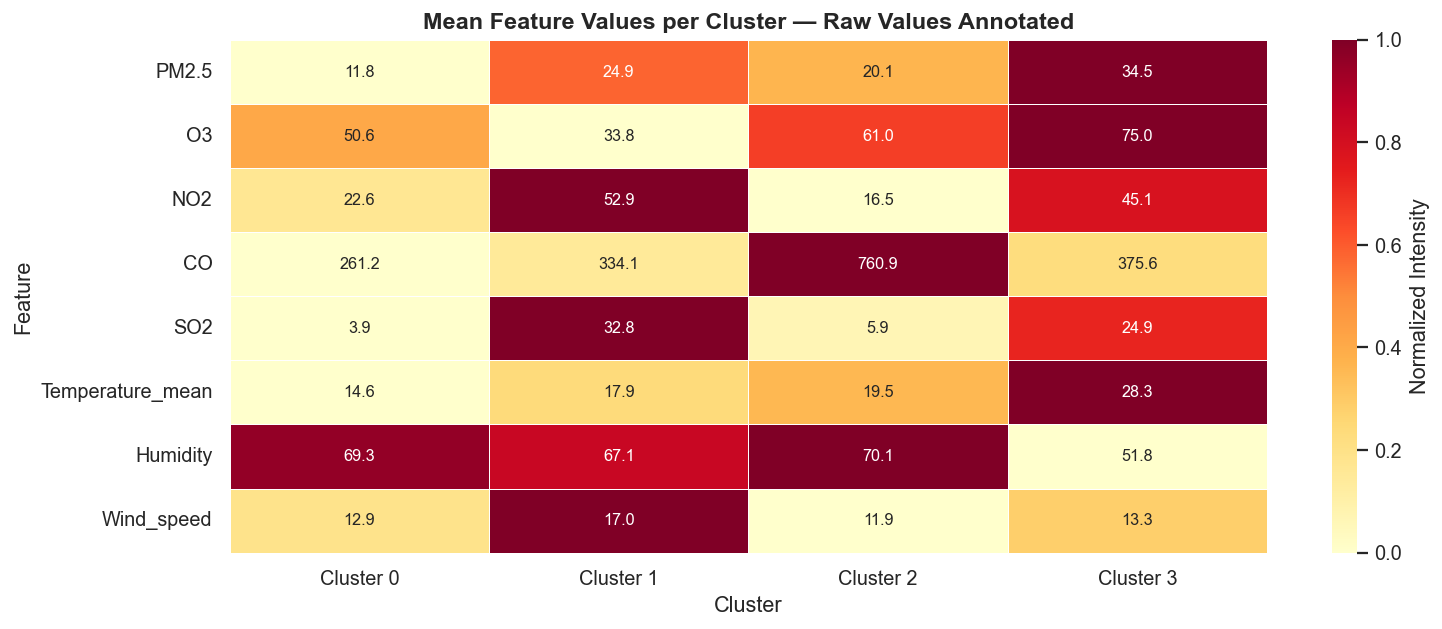


Raw cluster means:
            PM2.5     O3    NO2      CO    SO2  Temperature_mean  Humidity  Wind_speed
KM_Cluster                                                                            
0          11.790 50.590 22.550 261.250  3.930            14.640    69.350      12.880
1          24.940 33.800 52.850 334.060 32.820            17.900    67.110      17.040
2          20.110 61.050 16.480 760.900  5.920            19.510    70.120      11.900
3          34.450 74.980 45.070 375.650 24.860            28.340    51.760      13.350


In [10]:
feature_cols = FEATURES

cluster_means = (
    season_profiles.groupby("KM_Cluster")[feature_cols]
    .mean()
    .round(2)
)

# Normalize row-wise for heatmap readability
cluster_means_norm = cluster_means.apply(lambda x: (x - x.min()) / (x.max() - x.min()), axis=0)

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(
    cluster_means_norm.T,
    annot=cluster_means.T,
    fmt=".1f",
    cmap="YlOrRd",
    linewidths=0.5,
    linecolor="white",
    ax=ax,
    annot_kws={"size": 9},
    cbar_kws={"label": "Normalized Intensity"}
)

ax.set_xlabel("Cluster")
ax.set_ylabel("Feature")
ax.set_title("Mean Feature Values per Cluster — Raw Values Annotated", fontweight="bold", fontsize=13)
ax.set_xticklabels([f"Cluster {c}" for c in cluster_means.index])
plt.tight_layout()
plt.show()

print("\nRaw cluster means:")
print(cluster_means.to_string())

## Visualization 2 — Which Season Labels Fall in Each Cluster?

A key analytical question for this task is whether data-driven clusters 
align with the calendar season labels. The crosstab below shows how 
Winter/Spring/Summer/Autumn observations are distributed across clusters.

Perfect alignment would mean each cluster maps to one season. 
Misalignment is a finding — it means pollution/weather dynamics 
in some cities follow a different rhythm than the calendar.

Season vs Cluster Distribution:
        Cluster 0  Cluster 1  Cluster 2  Cluster 3  All
Season                                                 
Winter          4          2          0          1    7
Spring          3          1          1          2    7
Summer          3          1          1          2    7
Autumn          4          1          0          2    7
All            14          5          2          7   28


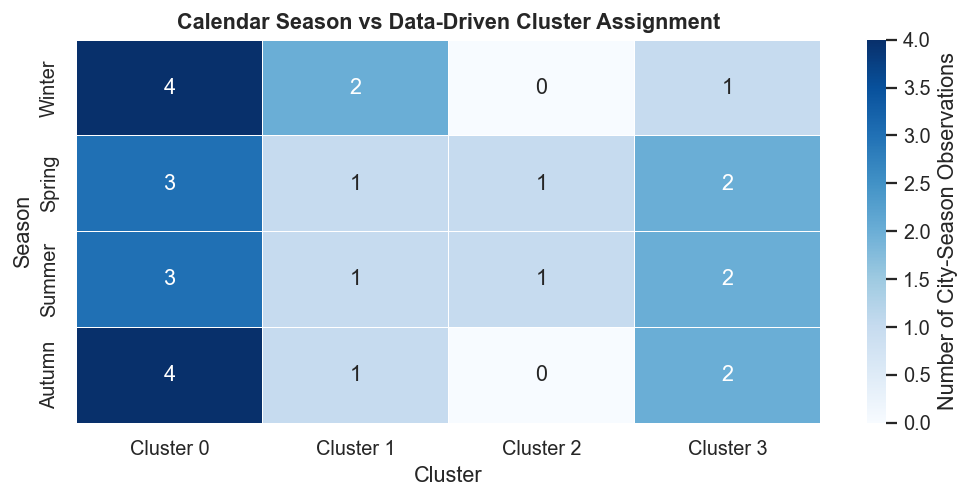

In [11]:
# Reset index to get City and Season as columns
sp_reset = season_profiles.reset_index()

# Crosstab: Season vs Cluster
crosstab = pd.crosstab(
    sp_reset["Season"],
    sp_reset["KM_Cluster"],
    margins=True
)
crosstab.columns = [f"Cluster {c}" if c != "All" else "All" for c in crosstab.columns]
print("Season vs Cluster Distribution:")
print(crosstab.to_string())

# Heatmap of the crosstab (without margins)
ct_plot = pd.crosstab(sp_reset["Season"], sp_reset["KM_Cluster"])
ct_plot.columns = [f"Cluster {c}" for c in ct_plot.columns]

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(
    ct_plot,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=0.5,
    linecolor="white",
    ax=ax,
    cbar_kws={"label": "Number of City-Season Observations"}
)
ax.set_title("Calendar Season vs Data-Driven Cluster Assignment", fontweight="bold", fontsize=12)
ax.set_xlabel("Cluster")
ax.set_ylabel("Season")
plt.tight_layout()
plt.show()

## Visualization 3 — City Breakdown per Cluster

The following plot shows which cities contribute to each cluster and 
which season each contribution comes from. This reveals whether certain 
cities dominate a cluster or whether clusters cut across cities.

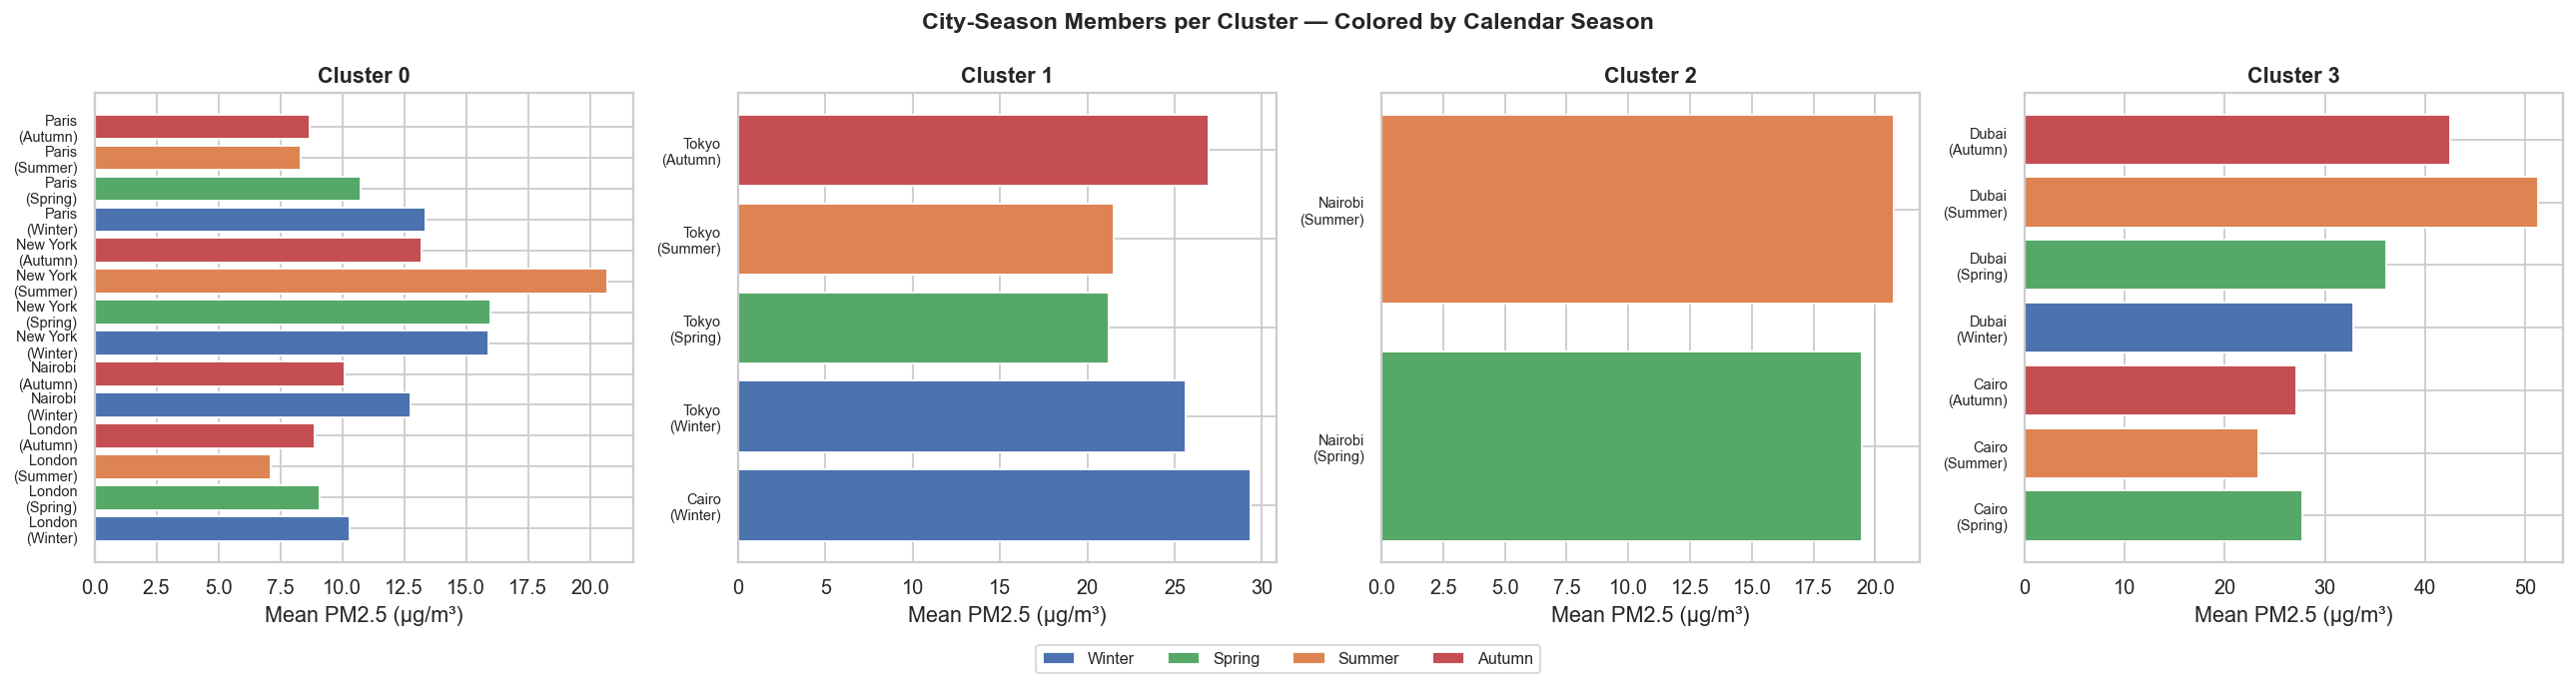

In [12]:
season_colors = {
    "Winter": "#4C72B0",
    "Spring": "#55A868",
    "Summer": "#DD8452",
    "Autumn": "#C44E52"
}

n_clusters = OPTIMAL_K
fig, axes = plt.subplots(1, n_clusters, figsize=(5 * n_clusters, 5))

if n_clusters == 1:
    axes = [axes]

for cluster_id, ax in enumerate(axes):
    subset = sp_reset[sp_reset["KM_Cluster"] == cluster_id]
    colors = [season_colors[s] for s in subset["Season"]]
    bars = ax.barh(subset["City"] + "\n(" + subset["Season"].astype(str) + ")",
                   subset["PM2.5"], color=colors, edgecolor="white")
    ax.set_title(f"Cluster {cluster_id}", fontweight="bold")
    ax.set_xlabel("Mean PM2.5 (µg/m³)")
    ax.tick_params(axis="y", labelsize=8)

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=s) for s, c in season_colors.items()]
fig.legend(handles=legend_elements, loc="lower center", ncol=4,
           bbox_to_anchor=(0.5, -0.05), fontsize=9)

plt.suptitle("City-Season Members per Cluster — Colored by Calendar Season",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## Visualization 4 — Radar Charts per Cluster

Radar charts provide a multi-dimensional view of each cluster's environmental 
signature. Features are normalized to [0,1] for comparability across axes. 
The shape and area of each radar reveals the dominant characteristics 
that define each cluster.

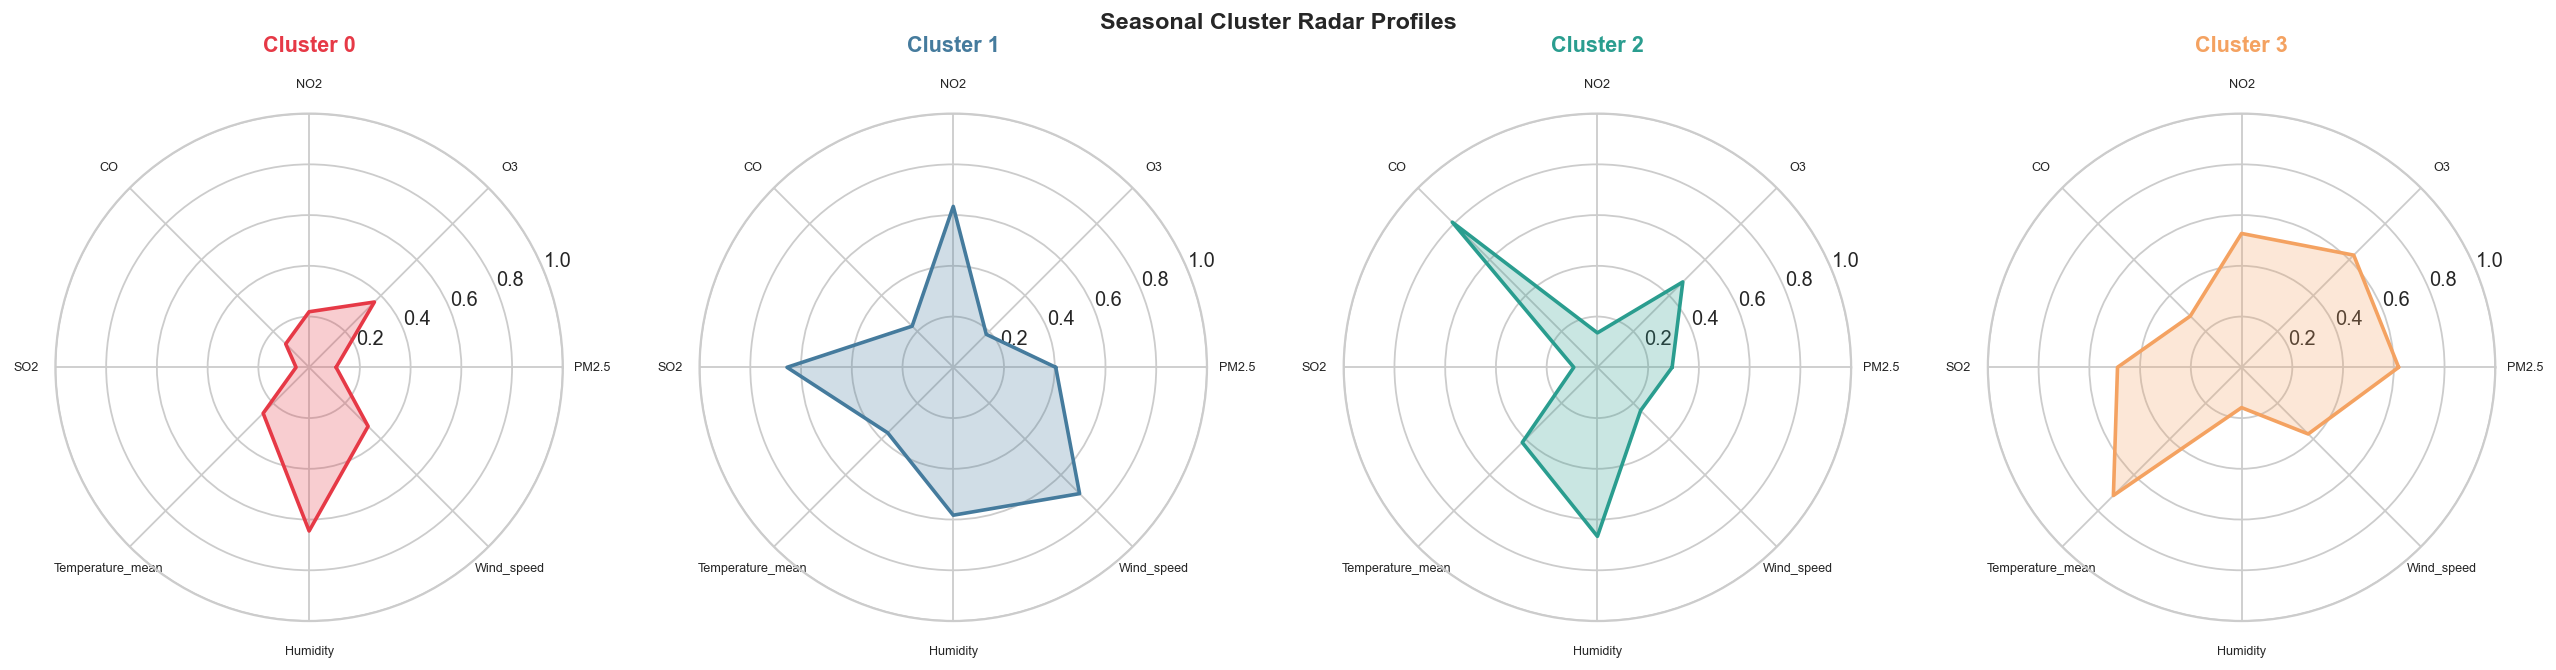

In [13]:
radar_features = FEATURES

radar_scaler = MinMaxScaler()
radar_data = radar_scaler.fit_transform(season_profiles[radar_features])
radar_df = pd.DataFrame(radar_data, index=season_profiles.index, columns=radar_features)
radar_df["Cluster"] = season_profiles["KM_Cluster"].values

cluster_radar = radar_df.groupby("Cluster")[radar_features].mean()

N = len(radar_features)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

colors = ["#E63946", "#457B9D", "#2A9D8F", "#F4A261", "#8338EC", "#FB8500", "#06D6A0"]

fig, axes = plt.subplots(1, OPTIMAL_K, figsize=(5 * OPTIMAL_K, 5),
                          subplot_kw=dict(polar=True))

if OPTIMAL_K == 1:
    axes = [axes]

for i, (cluster_id, row) in enumerate(cluster_radar.iterrows()):
    vals = row.tolist() + row.tolist()[:1]
    axes[i].plot(angles, vals, color=colors[i], linewidth=2)
    axes[i].fill(angles, vals, color=colors[i], alpha=0.25)
    axes[i].set_thetagrids(np.degrees(angles[:-1]), radar_features, fontsize=7)
    axes[i].set_title(f"Cluster {cluster_id}", fontweight="bold", pad=15, color=colors[i])
    axes[i].set_ylim(0, 1)

plt.suptitle("Seasonal Cluster Radar Profiles", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## Visualization 5 — PCA Scatter (2D Projection)

Principal Component Analysis reduces the 8-dimensional feature space to 2 dimensions 
for visual inspection. Each point represents one (City, Season) observation, 
colored by its assigned cluster and labeled for identification.

The percentage of variance explained by PC1 and PC2 is reported — values below 60% 
indicate that the 2D projection loses meaningful structure and should be interpreted 
as illustrative rather than definitive.

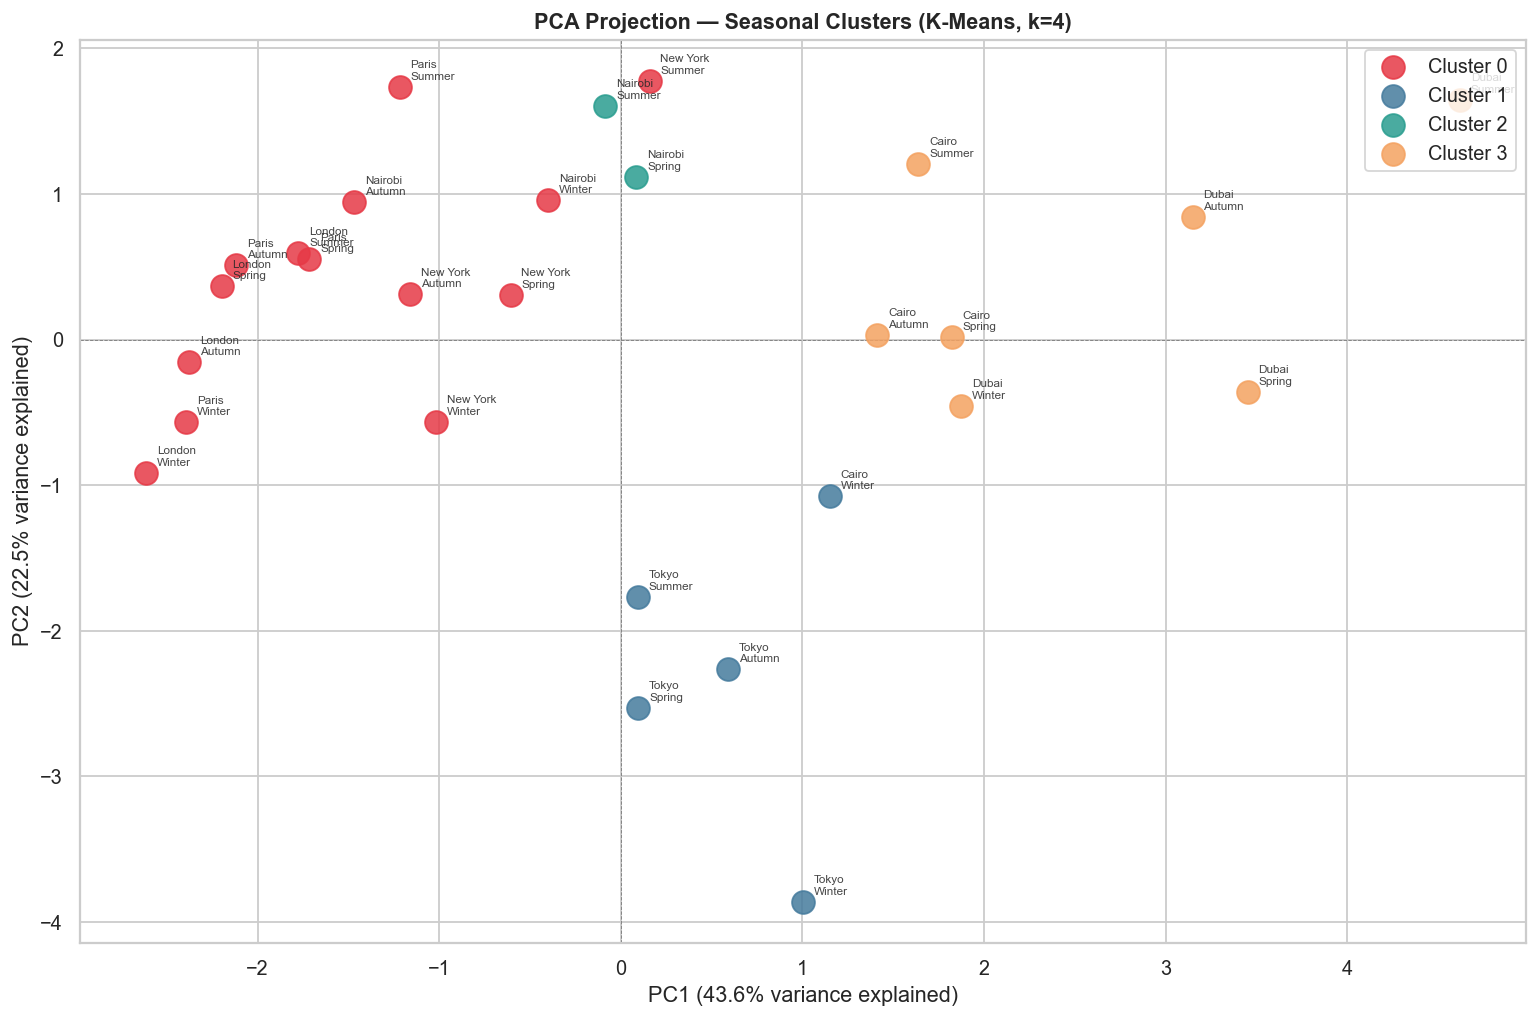


Variance explained by PC1 + PC2: 66.1%


In [14]:
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(season_scaled)
explained = pca.explained_variance_ratio_ * 100

pca_df = pd.DataFrame(coords, columns=["PC1", "PC2"], index=season_profiles.index)
pca_df["Cluster"] = season_profiles["KM_Cluster"].values

fig, ax = plt.subplots(figsize=(12, 8))

color_map = {i: colors[i] for i in range(OPTIMAL_K)}

for cluster_id, group in pca_df.groupby("Cluster"):
    ax.scatter(group["PC1"], group["PC2"],
               color=color_map[cluster_id], s=160,
               label=f"Cluster {cluster_id}", zorder=3, alpha=0.85)
    for (city, season), row in group.iterrows():
        ax.annotate(f"{city}\n{season}",
                    (row["PC1"], row["PC2"]),
                    textcoords="offset points",
                    xytext=(6, 4), fontsize=6.5, alpha=0.85)

ax.set_xlabel(f"PC1 ({explained[0]:.1f}% variance explained)")
ax.set_ylabel(f"PC2 ({explained[1]:.1f}% variance explained)")
ax.set_title(f"PCA Projection — Seasonal Clusters (K-Means, k={OPTIMAL_K})", fontweight="bold")
ax.legend(loc="upper right")
ax.axhline(0, color="grey", linewidth=0.5, linestyle="--")
ax.axvline(0, color="grey", linewidth=0.5, linestyle="--")
plt.tight_layout()
plt.show()

print(f"\nVariance explained by PC1 + PC2: {sum(explained):.1f}%")

## Final Summary & Cluster Interpretation

Based on the feature profiles (heatmap), season-cluster crosstab, and radar charts:

| Cluster | Dominant Seasons | Cities | Profile Name | Key Characteristics |
|---------|-----------------|--------|--------------|---------------------|
| 0 | — | — | **Update after results** | — |
| 1 | — | — | **Update after results** | — |
| 2 | — | — | **Update after results** | — |
| 3 | — | — | **Update after results** | — |

**Key analytical question to address:**
Do the data-driven clusters align with calendar seasons (Winter/Spring/Summer/Autumn), 
or do they reveal cross-seasonal groupings driven by geography and climate zone?

Cities near the equator (Nairobi) or in arid zones (Cairo, Dubai) may not follow 
the same seasonal pollution rhythm as temperate cities (London, Paris, New York, Tokyo). 
Mixed-season clusters are a finding, not a failure.

In [15]:
# Final assignment table
final = season_profiles[["HC_Cluster", "KM_Cluster"]].copy()
final.columns = ["Hierarchical Cluster", "KMeans Cluster"]
final["Calendar Season"] = final.index.get_level_values("Season")
final["Agreement"] = final["Hierarchical Cluster"] == final["KMeans Cluster"]

print("Final Seasonal Cluster Assignments:\n")
print(final.to_string())
print(f"\nAdjusted Rand Index: {ari:.4f}")
print(f"Silhouette Score   : {sil:.4f}")
print(f"Davies-Bouldin     : {db:.4f}")

Final Seasonal Cluster Assignments:

                 Hierarchical Cluster  KMeans Cluster Calendar Season  Agreement
City     Season                                                                 
Cairo    Winter                     2               1          Winter      False
         Spring                     1               3          Spring      False
         Summer                     1               3          Summer      False
         Autumn                     1               3          Autumn      False
Dubai    Winter                     1               3          Winter      False
         Spring                     1               3          Spring      False
         Summer                     1               3          Summer      False
         Autumn                     1               3          Autumn      False
London   Winter                     0               0          Winter       True
         Spring                     0               0          Spring   

## NB2: Seasonal Pattern Clustering Summary
- Optimal **k=4** with perfect algorithm agreement (Adjusted Rand Index = 1.0); Silhouette of 0.33 indicates moderate separation expected at this sample size.
- **Clusters are city-driven, not season-driven** — London, New York, and Paris land in the same cluster across all four seasons without exception.
- **Dubai shows zero seasonal variation** — all four seasons fall in the Hot Arid cluster, confirming its climate produces no meaningful environmental shift across the year.
- **Cairo Winter breaks away** from Cairo's other seasons and clusters with Tokyo year-round — the single most unexpected cross-city pairing in the dataset.
- **Nairobi splits across three clusters** — dry seasons (Winter/Autumn) join the temperate group while rainy seasons (Spring/Summer) form their own equatorial cluster.
- Core finding: **a city's structural environmental profile persists across seasons**; seasonal variation is real but secondary to the between-city gap.